In [2]:
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler,TargetEncoder, LabelEncoder, PowerTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, root_mean_squared_error, ConfusionMatrixDisplay,classification_report, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
#ROOT_DIR = Path().resolve().parent.parent
#DATA_DIR = ROOT_DIR / "data/raw"
#file_path = 'Telco_customer_churn.csv'

#Leer el archivo csv con pandas
#df = pd.read_csv(DATA_DIR / file_path, header=0, na_values=[' '])
df = pd.read_csv("http://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
    header=None,
    names=['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship',
           'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'])
#Mostrar las 5 primeras filas del dataframe
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
df['income'] = df['income'].apply(lambda x: 1 if x.strip() == '>50K' else 0)

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(['capital-gain','income'], axis=1)
y = df['income']
#primero siempre se dividen los datos en entrenamiento y prueba, luego se hace el preprocesamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, train_size=0.7)
print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (22792, 13)
Tamaño del conjunto de prueba es: (9769, 13)


In [6]:
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    PowerTransformer,
    StandardScaler,
    TargetEncoder
)

ss = StandardScaler() 
pt = PowerTransformer()
orden_education = [' Preschool', ' 1st-4th', ' 5th-6th', ' 7th-8th', ' 9th', ' 10th', ' 11th', ' 12th',
         ' HS-grad',' Some-college', ' Assoc-acdm', ' Assoc-voc', ' Bachelors', ' Masters',
         ' Prof-school', ' Doctorate']

ore_education = OrdinalEncoder(categories=[orden_education], dtype='int', max_categories=6) # aqui reducimos a solo 6 categorias las de alta cardinalidad ordinales

ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore') 
oheAC = OneHotEncoder(sparse_output=False, drop='first', max_categories=6, handle_unknown='ignore') 

In [7]:
from sklearn.compose import ColumnTransformer

#Aqui se define el preprocesador completo, indicando qué preprocesador se aplicará a cada variable. 
# Las demás columnas se descartan con remainder='drop'

preprocessor = ColumnTransformer(transformers=[
    ('power_transformer', pt, ['hours-per-week']),
    ('od_education_ac', ore_education, ['education']),
    ('std_one_hot_encoder', ohe, ['race','sex','workclass', 'relationship','marital-status']),
    ('one_hot_encoder_ac', oheAC, ['occupation', 'native-country'])
    ], remainder='drop') # Las demás columnas se descartan

<h2> Regression lineal </h2>

In [8]:
pipelineLinearR = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
pipelineLinearR

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('power_transformer', ...), ('od_education_ac', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_thre

In [9]:
pipelineLinearR.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['age','workclass','fnlwgt',...,'capital-loss','hours-per-week', 'native-country']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('power_transformer', ...), ('od_education_ac', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatica

In [10]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error

y_pred = pipelineLinearR.predict(X_train)

mse = mean_squared_error(y_train, y_pred)
rmse = root_mean_squared_error(y_train, y_pred)
from sklearn.metrics import r2_score

r2 = r2_score(y_train, y_pred)
print("R2 entrenamiento:", r2)
print("MSE entrenamiento:", mse)
print("RMSE:", rmse)

R2 entrenamiento: 0.3050992751629569
MSE entrenamiento: 0.12912758497453947
RMSE: 0.3593432689985155


In [11]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error

y_pred = pipelineLinearR.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 prueba:", r2)
print("MSE prueba:", mse)
print("RMSE:", rmse)

R2 prueba: 0.2891741653871568
MSE prueba: 0.12478639496825998
RMSE: 0.35325117829705815


/home/lenin/Documentos/universidad/analisis de datos/ap-2026-1-61/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


un caos y muy poco preciso asi que tratamos de aumentar los grados con la funcion polinomial

Aumentar dimensionalidad con funcion polinomial

In [12]:
from sklearn.preprocessing import PolynomialFeatures

pipelineLinearR = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
])
pipelineLinearR.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['age','workclass','fnlwgt',...,'capital-loss','hours-per-week', 'native-country']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('power_transformer', ...), ('od_education_ac', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automa

<h2> Modelo Ridge </h2>

implementar funcion Ridge

In [13]:
pipelineRidge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', Ridge(alpha=1.0))
])


sintonizar hiper parametros ridge

In [14]:
from sklearn.model_selection import GridSearchCV

grid = {
    'model__alpha': np.logspace(-4, 4, 50),
    'poly__degree': [1, 2]
}

grid_search = GridSearchCV(
    estimator=pipelineRidge,
    param_grid=grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(
    f"Mejor RMSE: {-grid_search.best_score_:.3f}\n"
    f"Mejores parámetros: {grid_search.best_params_}"
)

Mejor RMSE: 0.349
Mejores parámetros: {'model__alpha': np.float64(109.85411419875572), 'poly__degree': 2}


<h2> Modelo Lasso </h2>

implementar funcion Lasso

In [15]:
pipelineLasso = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=1, include_bias=False)),
    ('model', Lasso())
])


sintonizar hiper parametros lasso

In [16]:
from sklearn.model_selection import GridSearchCV

grid = {
    
    'model__alpha': np.logspace(-4, 4, 50),
    'poly__degree': [1, 2]
}

grid_search = GridSearchCV(
    estimator=pipelineLasso,
    param_grid=grid,
    scoring='r2',
    cv=5,
    n_jobs=7
)

grid_search.fit(X_train, y_train)


/home/lenin/Documentos/universidad/analisis de datos/ap-2026-1-61/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.409874e-01, tolerance: 3.380e-01
  model = cd_fast.enet_coordinate_descent(
/home/lenin/Documentos/universidad/analisis de datos/ap-2026-1-61/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.091832e+00, tolerance: 3.396e-01
  model = cd_fast.enet_coordinate_descent(
/home/lenin/Documentos/universidad/analisis de datos/ap-2026-1-61/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Obje

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Lasso())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': array([1.0000...00000000e+04]), 'poly__degree': [1, 2]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",7
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of

mostrar tabla de variables con mayor peso

In [17]:
best_model = grid_search.best_estimator_

preprocessor = best_model.named_steps['preprocessor']
poly = best_model.named_steps['poly']
lasso = best_model.named_steps['model']

feature_names = preprocessor.get_feature_names_out()
feature_names_poly = poly.get_feature_names_out(feature_names)

import pandas as pd

coef_df = pd.DataFrame({
    'variable': feature_names_poly,
    'coeficiente': lasso.coef_
})
coef_df

,variable,coeficiente
0,power_transformer__hours-per-week,0.031649
1,od_education_ac__education,0.084485
2,std_one_hot_encoder__race_ Asian-Pac-Islander,0.000000
3,std_one_hot_encoder__race_ Black,-0.000000
4,std_one_hot_encoder__race_ Other,-0.000000
...,...,...
697,one_hot_encoder_ac__native-country_ Philippine...,0.000000
698,one_hot_encoder_ac__native-country_ Philippine...,0.000000
699,one_hot_encoder_ac__native-country_ United-Sta...,0.000000
700,one_hot_encoder_ac__native-country_ United-Sta...,0.000000


In [18]:
#mostrar variables conservadas
coef_df['descartada'] = coef_df['coeficiente'] == 0

coef_df.sort_values(
    by=['descartada', 'coeficiente'],
    ascending=[False, False]
)

,variable,coeficiente,descartada
2,std_one_hot_encoder__race_ Asian-Pac-Islander,0.000000,True
3,std_one_hot_encoder__race_ Black,-0.000000,True
4,std_one_hot_encoder__race_ Other,-0.000000,True
5,std_one_hot_encoder__race_ White,0.000000,True
6,std_one_hot_encoder__sex_ Male,0.000000,True
...,...,...,...
316,std_one_hot_encoder__workclass_ Local-gov one_...,-0.099078,False
411,std_one_hot_encoder__workclass_ Self-emp-not-i...,-0.100979,False
591,std_one_hot_encoder__marital-status_ Married-c...,-0.104307,False
497,std_one_hot_encoder__relationship_ Other-relat...,-0.115072,False


<h2> Regression Logistica </h2>

Como ninguna de esas se acerca a alguna aproximacion real, vamos a pasar a modelos de regresion logistica

In [33]:
from sklearn.linear_model import LogisticRegression

pipelineLogistico = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('polinomial', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LogisticRegression( solver='liblinear', max_iter=100))
])

pipelineLogistico.fit(X_train, y_train)
print(f'La exactitud de este modelo con los datos de entrenamiento es: {pipelineLogistico.score(X_train, y_train):.3f}')
print(f'La exactitud de este modelo con los datos de prueba es: {pipelineLogistico.score(X_test, y_test):.3f}')

La exactitud de este modelo con los datos de entrenamiento es: 0.832
La exactitud de este modelo con los datos de prueba es: 0.833


/home/lenin/Documentos/universidad/analisis de datos/ap-2026-1-61/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [28]:
pipelineLogistico

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('polinomial', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['age','workclass','fnlwgt',...,'capital-loss','hours-per-week', 'native-country']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('power_transformer', ...), ('od_education_ac', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop

In [21]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pipelineLogistico.predict(X_test)));

              precision    recall  f1-score   support

           0       0.87      0.92      0.89      7550
           1       0.65      0.52      0.58      2219

    accuracy                           0.83      9769
   macro avg       0.76      0.72      0.73      9769
weighted avg       0.82      0.83      0.82      9769



/home/lenin/Documentos/universidad/analisis de datos/ap-2026-1-61/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/home/lenin/Documentos/universidad/analisis de datos/ap-2026-1-61/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


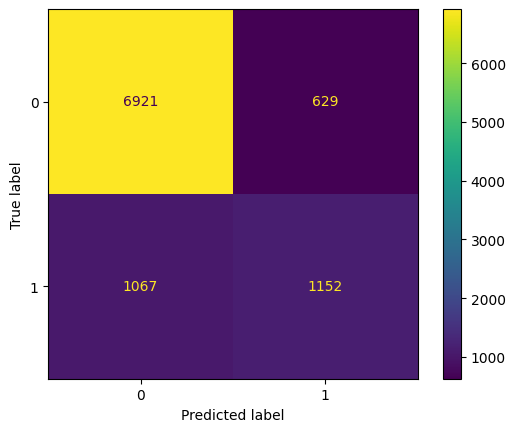

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(pipelineLogistico, X_test, y_test);

In [23]:
modelo = pipelineLogistico.named_steps['model']
preprocessor = pipelineLogistico.named_steps['preprocessor']
nombres_variables = preprocessor.get_feature_names_out()
coeficientes = pd.DataFrame(modelo.coef_.reshape(-1,1), index=nombres_variables, columns=['Coeficiente'])
coeficientes.loc['Intercepto'] = modelo.intercept_
coeficientes.sort_values(by='Coeficiente', ascending=False)

,Coeficiente
std_one_hot_encoder__marital-status_ Married-AF-spouse,1.766111
std_one_hot_encoder__marital-status_ Married-civ-spouse,1.674196
std_one_hot_encoder__relationship_ Wife,1.179622
one_hot_encoder_ac__occupation_ Prof-specialty,1.138640
one_hot_encoder_ac__occupation_ Exec-managerial,1.094743
std_one_hot_encoder__sex_ Male,0.887525
std_one_hot_encoder__race_ White,0.719183
one_hot_encoder_ac__native-country_ Philippines,0.718367
std_one_hot_encoder__race_ Asian-Pac-Islander,0.710546
one_hot_encoder_ac__native-country_ Germany,0.581345


Sintonizacion de la regresion logistica

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score

pipelineLogistico = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression( solver='liblinear', max_iter=100))
])

grid = {
    'model__l1_ratio':[0,1],
    'model__C':np.logspace(-3,3,10)
    #'l1_ratio':[0, 0.1, 0.5, 0.9, 1] # si tipo de regularización es elasticnet, define que tanto peso se la da a cada tipo de regularización
    }

grid_search = GridSearchCV(
    estimator=pipelineLogistico,
    param_grid=grid,
    #cv=5,
    scoring='accuracy',
    n_jobs=-1
    )

grid_search.fit(X_train, y_train)

print(f'Cross-validation score: {grid_search.best_score_:.3f}, best hyperparameters: {grid_search.best_params_}')
print(f'Train score: {grid_search.score(X_train, y_train):.3f}')
print(f'Test score: {grid_search.score(X_test, y_test):.3f}')

Cross-validation score: 0.818, best hyperparameters: {'model__C': np.float64(0.46415888336127775), 'model__l1_ratio': 1}
Train score: 0.818
Test score: 0.827


/home/lenin/Documentos/universidad/analisis de datos/ap-2026-1-61/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
